# Solar Flux Prediction

In [1]:
import torch

device_try = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Selected device: {device_try}")

Selected device: cuda


In [2]:
import os

print("=== TEST TMUX ===")
tmux_var = os.environ.get("TMUX")

if tmux_var:
    print("STATUS: Jupyter server is running in a TMUX session!")
    print(f"Tmux socket path: {tmux_var}")
else:
    print("STATUS: The Jupyter server is NOT inside Tmux (it runs in the global terminal).")

=== TEST TMUX ===
STATUS: Jupyter server is running in a TMUX session!
Tmux socket path: /tmp/tmux-1022/default,126489,1


In [3]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [4]:
print("--- Caricamento e Aggregazione Giornaliera ---")
df = pd.read_csv("../Data/MARSIS_historical_dataset.csv", sep=";")
df.columns = df.columns.str.strip()

# 1. Conversione tempo
df['datetime'] = pd.to_datetime(df['FM_data_ephemeris_time'], unit='s', origin=pd.Timestamp('2000-01-01 12:00:00'))

# 2. Aggregazione Giornaliera
df_daily = df.groupby(df['datetime'].dt.to_period('D')).agg({
    'FM_data_F10_7_index': 'mean'
}).reset_index()

df_daily['datetime'] = df_daily['datetime'].dt.to_timestamp()

# 3. FIX: Riempimento giorni mancanti PRIMA di estrarre le feature temporali
df_daily = df_daily.set_index('datetime').asfreq('D', method='ffill').reset_index()

# 4. Estrazione feature temporali (ora su un calendario perfetto e senza buchi)
df_daily['day_of_year'] = df_daily['datetime'].dt.dayofyear
df_daily['month_of_year'] = df_daily['datetime'].dt.month 

print(f"Dataset giornaliero creato. Totale giorni disponibili: {len(df_daily)}")

--- Caricamento e Aggregazione Giornaliera ---
Dataset giornaliero creato. Totale giorni disponibili: 5532


In [5]:
import numpy as np
from time_series_utils import *

LOOKBACK_WINDOW = 30 

# Creiamo le matrici usando il dataset giornaliero e il giorno dell'anno
X_flux, X_time, y = create_dataset_windows(
    data=df_daily, 
    target_col='FM_data_F10_7_index', 
    time_col='day_of_year',  
    lookback=LOOKBACK_WINDOW
)

# Split Cronologico (80% Train, 20% Test)
split_idx = int(len(y) * 0.8)

X_flux_train, X_flux_test = X_flux[:split_idx], X_flux[split_idx:]
X_time_train, X_time_test = X_time[:split_idx], X_time[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

## Linear regression for solar flux prediction 

In [6]:
print("\n--- Training: Regressione Lineare ---")

# Uniamo le feature (Flusso_t-30...Flusso_t + Giorno_t-30...Giorno_t)
X_linear_train = np.hstack((X_flux_train, X_time_train))
X_linear_test = np.hstack((X_flux_test, X_time_test))

# Inizializzazione e fit
lr_model = LinearRegression()
lr_model.fit(X_linear_train, y_train)

# Predizione e Valutazione
y_pred_lr = lr_model.predict(X_linear_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
print(f"[Linear Regression] Test MAE: {mae_lr:.3f}, Test RMSE: {rmse_lr:.3f}")


--- Training: Regressione Lineare ---
[Linear Regression] Test MAE: 0.401, Test RMSE: 1.352


## LSTM for solar flux prediction

In [7]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

print("\n--- Training: PyTorch LSTM (Dati Giornalieri) ---")

# =====================================================================
# 1. NORMALIZZAZIONE DEI DATI
# =====================================================================
# Inizializziamo gli scaler dedicati
scaler_X_flux = MinMaxScaler()
scaler_X_time = MinMaxScaler()
scaler_y = MinMaxScaler()

# Fit sul train e transform su train e test
X_flux_train_scaled = scaler_X_flux.fit_transform(X_flux_train)
X_flux_test_scaled = scaler_X_flux.transform(X_flux_test)

X_time_train_scaled = scaler_X_time.fit_transform(X_time_train)
X_time_test_scaled = scaler_X_time.transform(X_time_test)

y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1))

# COSTRUIAMO L'INPUT 3D RICHIESTO DALLA LSTM: (Campioni, Finestra, Feature)
# Uniamo il flusso e il giorno dell'anno lungo l'ultimo asse (axis=-1)
X_lstm_train = np.stack((X_flux_train_scaled, X_time_train_scaled), axis=-1)
X_lstm_test = np.stack((X_flux_test_scaled, X_time_test_scaled), axis=-1)



--- Training: PyTorch LSTM (Dati Giornalieri) ---


### 100 epochs

In [8]:
from utils.train_pytorch_model import *
from models.LSTM import *

# Avviamo l'addestramento usando la tua funzione modificata
# Passiamo hidden_dim=32 alla fine; verrà catturato da **model_kwargs
trained_lstm, device, training_history = train_pytorch_model(
    X_train=X_lstm_train,         # I tuoi dati 3D (Campioni, 30, 2)
    y_train=y_train_scaled,       # Il target normalizzato
    input_dim=2,                  # Flusso solare + Giorno dell'anno
    model_class=LSTMRegressor,    # La classe del modello
    epochs=100,                   # Massimo numero di epoche
    patience=8,                   # Interrompi se la val_loss non migliora per 8 epoche
    batch_size=32,                # Dimensione del batch ottimale per dati giornalieri
    hidden_dim=32                 # <--- Parametro extra inoltrato alla LSTM!
)

# =====================================================================
# INFERENZA SUI DATI DI TEST (Utilizzando il modello addestrato)
# =====================================================================
trained_lstm.eval()
X_test_t = torch.tensor(X_lstm_test, dtype=torch.float32).to(device)

with torch.no_grad():
    y_pred_lstm_scaled = trained_lstm(X_test_t).cpu().numpy()

# De-normalizzazione per visualizzare i risultati in scala reale
y_pred_lstm = scaler_y.inverse_transform(y_pred_lstm_scaled).flatten()

# Calcolo delle metriche di performance finali
from sklearn.metrics import mean_absolute_error, mean_squared_error
mae_lstm = mean_absolute_error(y_test, y_pred_lstm)
rmse_lstm = np.sqrt(mean_squared_error(y_test, y_pred_lstm))

print(f"\n[LSTM Network] Test MAE: {mae_lstm:.3f}, Test RMSE: {rmse_lstm:.3f}")

Early stopping at epoch 76

[LSTM Network] Test MAE: 0.662, Test RMSE: 1.371


### 1000 epochs

In [9]:
from utils.train_pytorch_model import *
from models.LSTM import *

# Avviamo l'addestramento usando la tua funzione modificata
# Passiamo hidden_dim=32 alla fine; verrà catturato da **model_kwargs
trained_lstm_2, device_2, training_history_2 = train_pytorch_model(
    X_train=X_lstm_train,         # I tuoi dati 3D (Campioni, 30, 2)
    y_train=y_train_scaled,       # Il target normalizzato
    input_dim=2,                  # Flusso solare + Giorno dell'anno
    model_class=LSTMRegressor,    # La classe del modello
    epochs=1000,                   # Massimo numero di epoche
    patience=8,                   # Interrompi se la val_loss non migliora per 8 epoche
    batch_size=64,                # Dimensione del batch ottimale per dati giornalieri
    hidden_dim=256                 # <--- Parametro extra inoltrato alla LSTM!
)

# =====================================================================
# INFERENZA SUI DATI DI TEST (Utilizzando il modello addestrato)
# =====================================================================
trained_lstm_2.eval()
X_test_t_2 = torch.tensor(X_lstm_test, dtype=torch.float32).to(device_2)

with torch.no_grad():
    y_pred_lstm_scaled_2 = trained_lstm_2(X_test_t_2).cpu().numpy()

# De-normalizzazione per visualizzare i risultati in scala reale
y_pred_lstm_2 = scaler_y.inverse_transform(y_pred_lstm_scaled_2).flatten()

# Calcolo delle metriche di performance finali
from sklearn.metrics import mean_absolute_error, mean_squared_error
mae_lstm_2 = mean_absolute_error(y_test, y_pred_lstm_2)
rmse_lstm_2 = np.sqrt(mean_squared_error(y_test, y_pred_lstm_2))

print(f"\n[LSTM Network] Test MAE: {mae_lstm_2:.3f}, Test RMSE: {rmse_lstm_2:.3f}")

Early stopping at epoch 74

[LSTM Network] Test MAE: 0.477, Test RMSE: 1.321


## Saving models

In [10]:
from time_series_utils import *

In [11]:
# Impacchettiamo gli scaler in un dizionario
my_scalers = {
    'scaler_X_flux': scaler_X_flux,
    'scaler_X_time': scaler_X_time,
    'scaler_y': scaler_y
}

save_lstm_and_scalers(
    model=trained_lstm, 
    scalers_dict=my_scalers, 
    save_dir="saved_lstm", 
    model_name="lstm_100_epochs.pth", 
    scaler_name="lstm_scalers_100_epochs.pkl"
)

# Chiamiamo la funzione
save_lstm_and_scalers(
    model=trained_lstm_2, 
    scalers_dict=my_scalers, 
    save_dir="saved_lstm", 
    model_name="lstm_1000_epochs.pth", 
    scaler_name="lstm_scalers_1000_epochs.pkl"
)

✅ Operazione completata con successo!
   - Pesi modello salvati in: saved_lstm/lstm_100_epochs_20260525_195718.pth
   - Scaler salvati in:       saved_lstm/lstm_scalers_100_epochs_20260525_195718.pkl
✅ Operazione completata con successo!
   - Pesi modello salvati in: saved_lstm/lstm_1000_epochs_20260525_195718.pth
   - Scaler salvati in:       saved_lstm/lstm_scalers_1000_epochs_20260525_195718.pkl


### Creating artificial Test Set with LSTM predicted values

In [12]:
print("--- 1. Creazione del DataFrame delle predizioni LSTM (Out-of-Sample) ---")

# L'array 'y' dell'LSTM parte dopo LOOKBACK_WINDOW giorni.
# Lo split_idx definisce dove inizia il Test Set.
start_test_idx = LOOKBACK_WINDOW + split_idx

# Estraiamo le date esatte del Test Set
dates_for_lstm_test = df_daily['datetime'].iloc[start_test_idx:].values

# Creiamo un DataFrame con le predizioni cieche dell'LSTM a 1000 epoche
df_lstm_blind_test = pd.DataFrame({
    'datetime': dates_for_lstm_test,
    'Predicted_F10_7': y_pred_lstm_2
})

# Troviamo la data esatta in cui inizia il Test Set cronologico
split_date = df_lstm_blind_test['datetime'].min()
print(f"Lo split cronologico Train/Test avviene in data: {split_date}")
print(f"Giorni nel Test Set Cieco dell'LSTM: {len(df_lstm_blind_test)}")

--- 1. Creazione del DataFrame delle predizioni LSTM (Out-of-Sample) ---
Lo split cronologico Train/Test avviene in data: 2018-01-23 00:00:00
Giorni nel Test Set Cieco dell'LSTM: 1101


In [13]:
print("\n--- 2. Allineamento Temporale (Merge Asof) sui dati MARSIS ---")

# Ricarichiamo il dataset principale MARSIS se necessario
df_main = pd.read_csv("../Data/MARSIS_historical_dataset.csv", sep=";")
df_main['datetime'] = pd.to_datetime(df_main['FM_data_ephemeris_time'], unit='s', origin=pd.Timestamp('2000-01-01 12:00:00'))

# Filtriamo MARSIS prendendo SOLO i dati successivi alla data di split
df_marsis_test_only = df_main[df_main['datetime'] >= split_date].copy()

# =====================================================================
# CORREZIONE AUTOMATICA: Allineamento della precisione temporale [ns]
# =====================================================================
df_marsis_test_only['datetime'] = df_marsis_test_only['datetime'].astype('datetime64[ns]')
df_lstm_blind_test['datetime'] = df_lstm_blind_test['datetime'].astype('datetime64[ns]')

# Ordiniamo per il merge asincrono (ora i tipi coincidono perfettamente)
df_marsis_test_only = df_marsis_test_only.sort_values('datetime').reset_index(drop=True)
df_lstm_blind_test = df_lstm_blind_test.sort_values('datetime').reset_index(drop=True)

# Merge: a ogni riga MARSIS viene associata la predizione LSTM del giorno corrente/precedente
df_cascade_test = pd.merge_asof(
    df_marsis_test_only,
    df_lstm_blind_test,
    on='datetime',
    direction='backward'
)

# Rimuoviamo eventuali NaN nel caso ci siano disallineamenti iniziali
df_cascade_test = df_cascade_test.dropna(subset=['Predicted_F10_7'])
print(f"✅ Righe MARSIS nel Test Set Operativo: {len(df_cascade_test)}")


--- 2. Allineamento Temporale (Merge Asof) sui dati MARSIS ---
✅ Righe MARSIS nel Test Set Operativo: 899137


In [14]:
print("\n--- 3. Generazione dei Dataset di Test (Ideale vs Cascata) ---")

# SCENARIO 1: IDEALE (Controllo) - Usiamo i dati reali
df_test_ideal = df_cascade_test.copy()
# (La colonna FM_data_F10_7_index rimane quella originale vera)

# SCENARIO 2: CASCATA (Produzione) - Inganniamo il modello con le stime LSTM
df_test_cascade = df_cascade_test.copy()
df_test_cascade['FM_data_F10_7_index'] = df_test_cascade['Predicted_F10_7']

# Rimuoviamo la colonna di appoggio che non serve più
df_test_ideal = df_test_ideal.drop(columns=['Predicted_F10_7'])
df_test_cascade = df_test_cascade.drop(columns=['Predicted_F10_7'])

# Salvataggio su disco (opzionale ma consigliato per debug)
os.makedirs("../Data/Test_Sets", exist_ok=True)
df_test_ideal.to_csv("../Data/Test_Sets/MARSIS_Test_Ideal.csv", sep=";", index=False)
df_test_cascade.to_csv("../Data/Test_Sets/MARSIS_Test_Cascade.csv", sep=";", index=False)
print("File salvati con successo in ../Data/Test_Sets/")


--- 3. Generazione dei Dataset di Test (Ideale vs Cascata) ---
File salvati con successo in ../Data/Test_Sets/


In [15]:
from utils.data_processing import *

# =====================================================================
# STEP 1: GENERAZIONE DEL TRAIN SET (L'80% CRONOLOGICO ANTECEDENTE)
# =====================================================================
print("--- 1. Isolamento e salvataggio del Train Set (80%) ---")

# Prendiamo i dati storici antecedenti alla data di split dell'LSTM
df_marsis_train_only = df_main[df_main['datetime'] < split_date].copy()

# Rimuoviamo la colonna 'datetime' di servizio per ripristinare il formato MARSIS originale
df_marsis_train_only = df_marsis_train_only.drop(columns=['datetime'], errors='ignore')

train_csv_path = "../Data/Test_Sets/MARSIS_Train_Pure.csv"
df_marsis_train_only.to_csv(train_csv_path, sep=";", index=False)
print(f"Train Set originale salvato in: {train_csv_path}")


# =====================================================================
# STEP 2: PULIZIA E SALVATAGGIO DEI DATASET DI TEST (IL TUO CODICE FIXATO)
# =====================================================================
print("\n--- 2. Adeguamento e salvataggio dei Test Set (Ideale e Cascata) ---")

# Riprendiamo i tuoi df_test_ideal e df_test_cascade e puliamo la colonna 'datetime'
df_test_ideal_save = df_test_ideal.drop(columns=['datetime'], errors='ignore')
df_test_cascade_save = df_test_cascade.drop(columns=['datetime'], errors='ignore')

# Definiamo i percorsi di salvataggio
ideal_csv_path = "../Data/Test_Sets/MARSIS_Test_Ideal.csv"
cascade_csv_path = "../Data/Test_Sets/MARSIS_Test_Cascade.csv"

# Salvataggio definitivo dei file puliti
df_test_ideal_save.to_csv(ideal_csv_path, sep=";", index=False)
df_test_cascade_save.to_csv(cascade_csv_path, sep=";", index=False)
print("File di Test salvati correttamente pronti per la pipeline.")


# =====================================================================
# STEP 3: ESTRAZIONE MATRICI X, y TRAMITE load_and_preprocess_data
# =====================================================================
print("\n--- 3. Estrazione delle matrici finali tramite la pipeline standard ---")

# Definiamo il percorso del file delle orbite da escludere (adattalo se differisce)
orbit_file_path = "../Data/orbit_to_remove" 

# 1. Dataset di Addestramento (Usa il flusso solare VERO)
X_train, y_train, feature_names = load_and_preprocess_data(
    dataset_path=train_csv_path, 
    orbit_path=orbit_file_path, 
    keep_flux=True # La rete principale HA BISOGNO del flusso solare per imparare
)

# 2. Dataset di Test IDEALE (Controllo con flusso solare VERO)
X_test_ideal, y_test_ideal, _ = load_and_preprocess_data(
    dataset_path=ideal_csv_path, 
    orbit_path=orbit_file_path, 
    keep_flux=True
)

# 3. Dataset di Test IN CASCATA (Operativo con flusso solare STIMATO DA LSTM)
X_test_cascade, y_test_cascade, _ = load_and_preprocess_data(
    dataset_path=cascade_csv_path, 
    orbit_path=orbit_file_path, 
    keep_flux=True
)


# =====================================================================
# STEP 4: VERIFICA DI INTEGRITÀ SCIENTIFICA
# =====================================================================
print("\n" + "="*50)
print("🔍 VERIFICA DIMENSIONI DATASET E COERENZA FEATURE")
print("="*50)
print(f"Features utilizzate ({len(feature_names)}): {feature_names}")
print("-" * 50)
print(f"🏋️ TRAIN SET              -> X: {X_train.shape}  | y: {y_train.shape}")
print(f"🎯 TEST SET (IDEALE)     -> X: {X_test_ideal.shape}  | y: {y_test_ideal.shape}")
print(f"📡 TEST SET (CASCATA)    -> X: {X_test_cascade.shape}  | y: {y_test_cascade.shape}")
print("-" * 50)

# Controllo fondamentale: i due test set devono essere matematicamente identici come shape
assert X_test_ideal.shape == X_test_cascade.shape, "❌ ERRORE: Disallineamento tra Test Ideale e Cascata!"
assert np.array_equal(y_test_ideal, y_test_cascade), "❌ ERRORE: I target (Echo Power) del test non coincidono!"
print("✅ Tutto pronto! Le matrici sono allineate e prive di data leakage temporale.")

--- 1. Isolamento e salvataggio del Train Set (80%) ---
Train Set originale salvato in: ../Data/Test_Sets/MARSIS_Train_Pure.csv

--- 2. Adeguamento e salvataggio dei Test Set (Ideale e Cascata) ---
File di Test salvati correttamente pronti per la pipeline.

--- 3. Estrazione delle matrici finali tramite la pipeline standard ---

🔍 VERIFICA DIMENSIONI DATASET E COERENZA FEATURE
Features utilizzate (19): ['FM_data_altitude', 'FM_data_band', 'FM_data_dipole_tilt', 'FM_data_F10_7_index', 'FM_data_latitude', 'FM_data_local_true_solar_time', 'FM_data_longitude', 'FM_data_Mars_Sun_distance', 'FM_data_monopole_tilt', 'FM_data_radial_magnetic_field', 'FM_data_roughness', 'FM_data_slope', 'FM_data_Sun_elevation_angle', 'FM_data_tangential_magnetic_field', 'FM_data_total_magnetic_field', 'FM_data_x_coordinate', 'FM_data_y_coordinate', 'FM_data_solar_longitude_cos', 'FM_data_solar_longitude_sin']
--------------------------------------------------
🏋️ TRAIN SET              -> X: (1474165, 19)  | y:

### Model training

In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import torch
import os
from datetime import datetime
from joblib import dump
from models.neural_network import *

print("--- 1. Standardizzazione delle Feature ---")
# Inizializziamo lo scaler per la rete neurale
scaler_nn = StandardScaler()

# Fit solo sul Train Set vero, transform su tutti per evitare data leakage
X_train_scaled = scaler_nn.fit_transform(X_train)
X_test_ideal_scaled = scaler_nn.transform(X_test_ideal)
X_test_cascade_scaled = scaler_nn.transform(X_test_cascade)

print("--- 2. Addestramento della NeurNet Singola ---")
# Usiamo direttamente la tua funzione di training
# Assumiamo che tu abbia importato o definito la classe del tuo modello, ad esempio 'NeurNet'
# Sostituisci 'NeurNet' con il nome reale della classe della tua rete
input_dimension = X_train_scaled.shape[1]

main_model, device, history = train_pytorch_model(
    X_train=X_train_scaled, 
    y_train=y_train, 
    input_dim=input_dimension, 
    model_class=NeurNet,  # <-- ATTENZIONE: Inserisci qui la TUA classe PyTorch
    epochs=1000, 
    patience=10, 
    batch_size=256
)

# Salvataggio del modello finale per sicurezza
os.makedirs("saved_main_model", exist_ok=True)
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
scaler_save_path = f"saved_main_model/main_nn_scaler_{timestamp}.save"
torch.save(main_model.state_dict(), f"saved_main_model/main_nn_model_{timestamp}.pth")
dump(scaler_nn, scaler_save_path)
print("✅ Modello principale addestrato e salvato.")
print(f"✅ Scaler relativo salvato in: {scaler_save_path}")

--- 1. Standardizzazione delle Feature ---
--- 2. Addestramento della NeurNet Singola ---


Early stopping at epoch 13
✅ Modello principale addestrato e salvato.
✅ Scaler relativo salvato in: saved_main_model/main_nn_scaler_20260525_200849.save


### Testing model on true data and on artificially engineered (LSTM) data


--- 3. Valutazione Comparativa sui due Scenari (Ideale vs Cascata) ---
📊 REPORT FINALE: PERFORMANCE DELL'ESPERIMENTO A CASCATA
SCENARIO 1: FLUSSO SOLARE REALE (Baseline di Controllo)
  MAE:  2.6603
  RMSE: 3.4158
------------------------------------------------------------
SCENARIO 2: FLUSSO SOLARE DA LSTM (Simulazione Produzione)
  MAE:  2.6557
  RMSE: 3.4065
⚠️ Degrado delle performance causato dal cascade post LSTM:
   Aumento del MAE:  +-0.17%
   Aumento del RMSE: +-0.27%

Generazione del grafico comparativo unico...


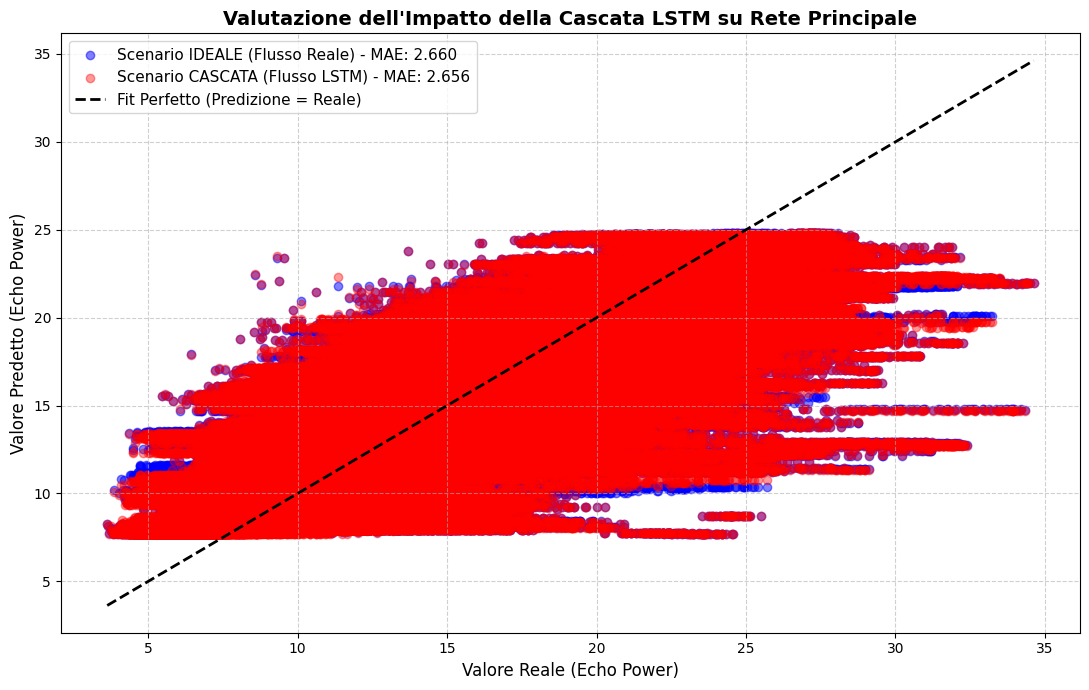

In [19]:
import matplotlib.pyplot as plt

print("\n--- 3. Valutazione Comparativa sui due Scenari (Ideale vs Cascata) ---")

# 1. Mettiamo il modello in modalità inferenza (disabilita Dropout, BatchNorm, etc.)
main_model.eval()

# 2. Convertiamo i Test Set (già scalati) in Tensori PyTorch
X_ideal_tensor = torch.tensor(X_test_ideal_scaled, dtype=torch.float32).to(device)
X_cascade_tensor = torch.tensor(X_test_cascade_scaled, dtype=torch.float32).to(device)

# 3. Eseguiamo l'inferenza senza calcolare i gradienti
with torch.no_grad():
    # .cpu().numpy().flatten() riporta i dati dalla GPU/Tensor a un array 1D di NumPy
    y_pred_ideal = main_model(X_ideal_tensor).cpu().numpy().flatten()
    y_pred_cascade = main_model(X_cascade_tensor).cpu().numpy().flatten()

# 4. Calcolo delle metriche - SCENARIO 1: IDEALE (Dati Reali)
mae_ideal = mean_absolute_error(y_test_ideal, y_pred_ideal)
rmse_ideal = np.sqrt(mean_squared_error(y_test_ideal, y_pred_ideal))

# 5. Calcolo delle metriche - SCENARIO 2: CASCATA (Dati Predetti da LSTM)
mae_cascade = mean_absolute_error(y_test_cascade, y_pred_cascade)
rmse_cascade = np.sqrt(mean_squared_error(y_test_cascade, y_pred_cascade))

# 6. Report a schermo
print("="*60)
print("📊 REPORT FINALE: PERFORMANCE DELL'ESPERIMENTO A CASCATA")
print("="*60)
print("SCENARIO 1: FLUSSO SOLARE REALE (Baseline di Controllo)")
print(f"  MAE:  {mae_ideal:.4f}")
print(f"  RMSE: {rmse_ideal:.4f}")
print("-" * 60)
print("SCENARIO 2: FLUSSO SOLARE DA LSTM (Simulazione Produzione)")
print(f"  MAE:  {mae_cascade:.4f}")
print(f"  RMSE: {rmse_cascade:.4f}")
print("="*60)

# Calcolo del degrado delle performance
mae_degradation = ((mae_cascade - mae_ideal) / mae_ideal) * 100
rmse_degradation = ((rmse_cascade - rmse_ideal) / rmse_ideal) * 100

print(f"⚠️ Degrado delle performance causato dal cascade post LSTM:")
print(f"   Aumento del MAE:  +{mae_degradation:.2f}%")
print(f"   Aumento del RMSE: +{rmse_degradation:.2f}%")
print("="*60)

# =====================================================================
# EXTRA: Visualizzazione Grafica dei Risultati (Scenari Sovrapposti)
# =====================================================================
print("\nGenerazione del grafico comparativo unico...")

# Creiamo una sola figura invece di una griglia di sotto-grafici
plt.figure(figsize=(11, 7))

# 1. Plot dello Scenario Ideale (Punti Blu)
plt.scatter(y_test_ideal, y_pred_ideal, alpha=0.5, color='blue', 
            label=f'Scenario IDEALE (Flusso Reale) - MAE: {mae_ideal:.3f}')

# 2. Plot dello Scenario Cascata (Punti Rossi sovrapposti)
plt.scatter(y_test_cascade, y_pred_cascade, alpha=0.4, color='red', 
            label=f'Scenario CASCATA (Flusso LSTM) - MAE: {mae_cascade:.3f}')

# 3. Unica Linea di Fit Perfetto (i target reali sono identici)
plt.plot([y_test_ideal.min(), y_test_ideal.max()], 
         [y_test_ideal.min(), y_test_ideal.max()], 
         'k--', lw=2, label='Fit Perfetto (Predizione = Reale)')

# Configurazione del grafico unico
plt.title('Valutazione dell\'Impatto della Cascata LSTM su Rete Principale', fontsize=14, fontweight='bold')
plt.xlabel('Valore Reale (Echo Power)', fontsize=12)
plt.ylabel('Valore Predetto (Echo Power)', fontsize=12)

# La legenda raccoglierà automaticamente tutte le label definite sopra con le relative metriche
plt.legend(fontsize=11, loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## Solar flux prediction with LSTM and comparison with real targets

--- 1. Inizio K-Fold Cross Validation per LSTM ---

>> Esecuzione Fold 1/5...


Early stopping at epoch 56
   Media Target: 80.22 | Media Predetta: 80.15 | Salvato su predizioni_fold_1_20260722_124415.csv

>> Esecuzione Fold 2/5...


Early stopping at epoch 39
   Media Target: 75.72 | Media Predetta: 76.06 | Salvato su predizioni_fold_2_20260722_124415.csv

>> Esecuzione Fold 3/5...


Early stopping at epoch 64
   Media Target: 145.47 | Media Predetta: 145.26 | Salvato su predizioni_fold_3_20260722_124415.csv

>> Esecuzione Fold 4/5...


Early stopping at epoch 60
   Media Target: 119.04 | Media Predetta: 119.23 | Salvato su predizioni_fold_4_20260722_124415.csv

>> Esecuzione Fold 5/5...


Early stopping at epoch 76
   Media Target: 78.62 | Media Predetta: 78.59 | Salvato su predizioni_fold_5_20260722_124415.csv

--- 2. Generazione Grafici delle Distribuzioni (Istogrammi) ---


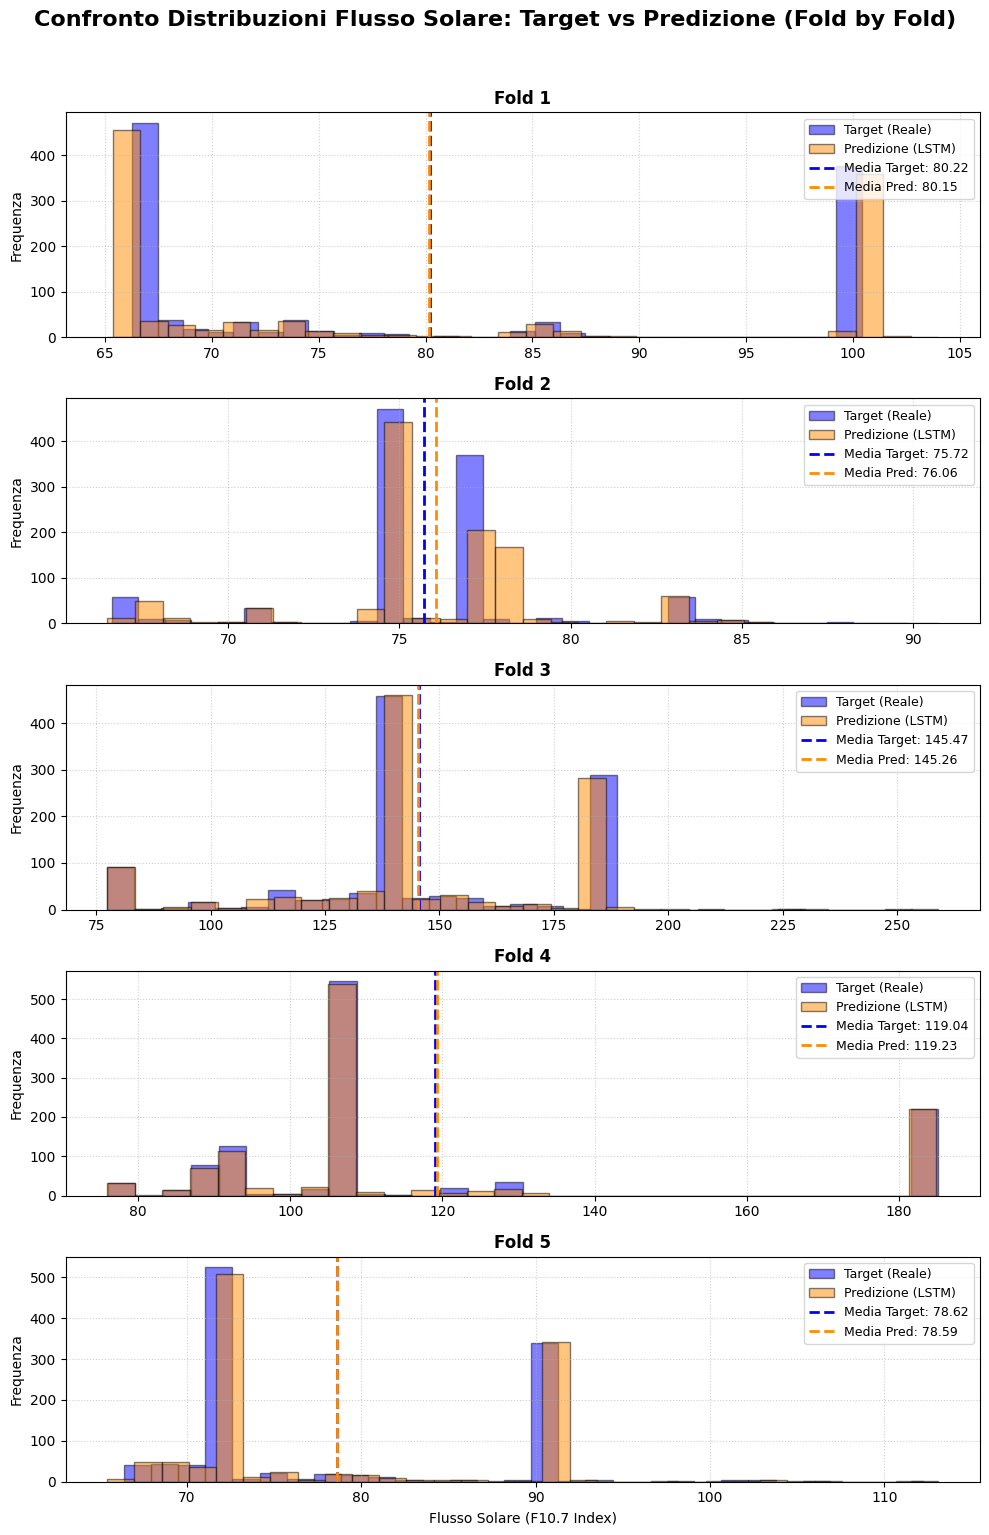

In [8]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from models.LSTM import LSTMRegressor
from utils.train_pytorch_model import train_pytorch_model
from datetime import datetime

print("--- 1. Inizio K-Fold Cross Validation per LSTM ---")

# Definiamo 5 fold senza rimescolamento (blocchi temporali)
n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=False)

# Dizionari per salvare i risultati di ogni fold
fold_results = {}

# Uniamo temporaneamente tutto il dataset per passarlo al K-Fold
X_lstm_all = np.stack((scaler_X_flux.fit_transform(X_flux), 
                       scaler_X_time.fit_transform(X_time)), axis=-1)
y_all_scaled = scaler_y.fit_transform(y.reshape(-1, 1))
timestamp_exp = datetime.now().strftime("%Y%m%d_%H%M%S")

fold = 1
for train_idx, test_idx in kf.split(X_lstm_all):
    print(f"\n>> Esecuzione Fold {fold}/{n_splits}...")
    
    # Divisione Train/Test per il fold corrente
    X_train_f, X_test_f = X_lstm_all[train_idx], X_lstm_all[test_idx]
    y_train_f, y_test_f = y_all_scaled[train_idx], y_all_scaled[test_idx]
    
    # Addestramento di una nuova LSTM per questo fold 
    model_f, device_f, _ = train_pytorch_model(
        X_train=X_train_f, y_train=y_train_f, input_dim=2,
        model_class=LSTMRegressor, epochs=1000, patience=8, 
        batch_size=64, hidden_dim=256
    )
    
    # Inferenza sul Test Set del fold
    model_f.eval()
    with torch.no_grad():
        X_test_tensor = torch.tensor(X_test_f, dtype=torch.float32).to(device_f)
        y_pred_scaled = model_f(X_test_tensor).cpu().numpy()
    
    # Denormalizzazione
    y_pred_real = scaler_y.inverse_transform(y_pred_scaled).flatten()
    y_target_real = scaler_y.inverse_transform(y_test_f).flatten()
    
    # Calcolo delle medie richieste per questo fold
    mean_target = np.mean(y_target_real)
    mean_pred = np.mean(y_pred_real)
    
    # Salvataggio dati
    fold_results[fold] = {
        'targets': y_target_real,
        'preds': y_pred_real,
        'mean_target': mean_target,
        'mean_pred': mean_pred
    }

    df_fold = pd.DataFrame({
        'Target_F10_7': y_target_real,
        'Predicted_F10_7': y_pred_real
    })
    
    nome_file = f"predizioni_fold_{fold}_{timestamp_exp}.csv"
    
    # Salvataggio su disco 
    df_fold.to_csv(nome_file, index=False)
    
    print(f"   Media Target: {mean_target:.2f} | Media Predetta: {mean_pred:.2f} | Salvato su {nome_file}")

    fold += 1

print("\n--- 2. Generazione Grafici delle Distribuzioni (Istogrammi) ---")

# Creiamo una figura con N righe (una per fold)
fig, axes = plt.subplots(nrows=n_splits, ncols=1, figsize=(10, 3 * n_splits))
fig.suptitle("Confronto Distribuzioni Flusso Solare: Target vs Predizione (Fold by Fold)", fontsize=16, fontweight='bold', y=1.02)

for i in range(1, n_splits + 1):
    ax = axes[i-1]
    data = fold_results[i]
    
    # Plot degli istogrammi in semitrasparenza (alpha) per vedere le sovrapposizioni
    ax.hist(data['targets'], bins=30, alpha=0.5, color='blue', label='Target (Reale)', edgecolor='black')
    ax.hist(data['preds'], bins=30, alpha=0.5, color='darkorange', label='Predizione (LSTM)', edgecolor='black')
    
    # Aggiungiamo le linee verticali per evidenziare le medie
    ax.axvline(data['mean_target'], color='blue', linestyle='dashed', linewidth=2, label=f"Media Target: {data['mean_target']:.2f}")
    ax.axvline(data['mean_pred'], color='darkorange', linestyle='dashed', linewidth=2, label=f"Media Pred: {data['mean_pred']:.2f}")
    
    ax.set_title(f"Fold {i}", fontsize=12, fontweight='bold')
    ax.set_ylabel("Frequenza")
    if i == n_splits:
        ax.set_xlabel("Flusso Solare (F10.7 Index)")
    
    # Spostiamo la legenda fuori o in una posizione che non copra i dati
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()